**Сборный проект: HR-аналитика**  

**Цель проекта** - помочь HR-аналитикам компании «Работа с заботой» оптимизировать управление персоналом, для реализации которой необходимо выполнить две задачи:  

1) Построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.

2) Предсказать отток сотрудников, для чего построить модель, которая сможет спрогнозировать увольнение сотрудника из компании

**Задача 1: предсказание уровня удовлетворённости сотрудника**  

План работ:  

1) Загрузить данные из файлов rain_job_satisfaction_rate.csv, test_features.csv, test_target_job_satisfaction_rate.csv, подготовить данные для последующего анализа.

2) При необходимости выполнить предобработку. При наличии пропущенных значений заполнить их в пайплайне.

3) Исследовать все признаки и сделать выводы о том, как их нужно подготовить.

4) Подготовку признаков выполнить в пайплайне, дополнив пайплайн шага предобработки. При кодировании учесть особенности признаков и моделей используя как минимум два кодировщика.

5) Обучить как минимум две модели: линейную и дерево решений. Подобрать гиперпараметры как минимум для моделей.

6) Выбрать лучшую модель и проверить её качество на основе новой метрики — SMAPE («симметричное среднее абсолютное процентное отклонение»). Написать функцию, которая принимает на вход массивы NumPy или объекты Series в pandas и возвращает значение метрики SMAPE.

7) Сделать промежуточные выводы о том, какая модель справилась лучше, аргументировать выводы.

**Задача 2: предсказание увольнения сотрудника из компании**  
План работ по задаче 2:  

1) Загрузить данные из файлов train_job_satisfaction_rate.csv, test_features.csv, test_target_quit.csv, подготовить данные для последующего анализа.

2) При необходимости выполнить предобработку. При наличии пропущенных значений заполнить их в пайплайне.

3) Провести исследовательский анализ данных.

4) Составить портрет «уволившегося сотрудника». Узнать, в каком отделе с большей вероятностью работает уволившийся сотрудник и какой у него уровень загруженности. Сравнить среднее значение зарплаты ушедших сотрудников с теми, кто остался в компании.

    Проверить утверждение, что уровень удовлетворённости сотрудника работой в компании влияет на то, уволится ли сотрудник.  Визуализировать и сравнить распределения признака job_satisfaction_rate для ушедших и оставшихся сотрудников.  

5) Добавить новый признак job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам второй задачи.

6) Выполните подготовку признаков в пайплайне, дополнив пайплайн предобработки. При кодировании учесть особенности признаков и моделей, использовать как минимум два кодировщика.

7) Обучить три модели, как минимум для двух из них подобрать гиперпараметры. Проверить качество лучшей модели с помощью метрики ROC-AUC (критерий успеха: ROC-AUC ≥ 0.91 на тестовой выборке).

8) Сделать и аргументировать промежуточные выводы о том, какая модель справилась лучше.

**Общий вывод по проекту**  
Сделать выводы и предложения по оптимизации управления персоналом.  

# Задача 1

## 1. Загрузка данных

In [2]:
!pip install phik -q
!pip install optuna-integration -q
!pip install imbalanced-learn -q
!pip install shap -q

In [3]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import phik
import seaborn as sns
import scipy.stats as st
import random
import shap
RANDOM_STATE = 42
TEST_SIZE = 0.25

from matplotlib import pyplot as plt
from phik import resources, report
from scipy.stats import spearmanr

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif 
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn import svm
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier 
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler,\
RobustScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder,\
PolynomialFeatures
from sklearn.datasets import make_classification
from sklearn.metrics import make_scorer
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, precision_score, accuracy_score,\
                            f1_score, roc_auc_score 
from sklearn.multiclass import OneVsRestClassifier

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE, SMOTENC, ADASYN

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score,\
                                    GridSearchCV, RandomizedSearchCV, train_test_split

from optuna.integration import OptunaSearchCV 

In [4]:
train_job = pd.read_csv('https://code.s3.yandex.net/datasets/train_job_satisfaction_rate.csv')
test_features = pd.read_csv('https://code.s3.yandex.net/datasets/test_features.csv')
test_target = pd.read_csv('https://code.s3.yandex.net/datasets/test_target_job_satisfaction_rate.csv')

In [5]:
display(train_job.head())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
0,155278,sales,junior,medium,2,no,no,1,24000,0.58
1,653870,hr,junior,high,2,no,no,5,38400,0.76
2,184592,sales,junior,low,1,no,no,2,12000,0.11
3,171431,technology,junior,low,4,no,no,2,18000,0.37
4,693419,hr,junior,medium,1,no,no,3,22800,0.20


In [6]:
display(test_features.head())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
0,485046,marketing,junior,medium,2,no,no,5,28800
1,686555,hr,junior,medium,1,no,no,4,30000
2,467458,sales,middle,low,5,no,no,4,19200
3,418655,sales,middle,low,6,no,no,4,19200
4,789145,hr,middle,medium,5,no,no,5,40800


In [7]:
display(test_target.head())

,id,job_satisfaction_rate
0,130604,0.74
1,825977,0.75
2,418490,0.60
3,555320,0.72
4,826430,0.08


Индексы в таблицах входных признаков и целевого признака расположены в разном порядке: далее нужно будет привести к одному порядку строки в обеих таблицах

## 2. Предобработка данных

In [8]:
train_job.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   object 
 2   level                  3996 non-null   object 
 3   workload               4000 non-null   object 
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   object 
 6   last_year_violations   4000 non-null   object 
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 312.6+ KB


In [9]:
train_job[train_job['dept'].isna()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1526,694746,NaN,junior,medium,5,no,no,4,21600,0.62
1630,814624,NaN,junior,medium,3,no,no,4,24000,0.88
1633,475114,NaN,junior,high,4,no,no,4,31200,0.63
2781,497243,NaN,junior,medium,1,no,no,3,26400,0.28
2975,168668,NaN,junior,low,3,no,no,4,18000,0.88
3866,641150,NaN,junior,low,3,no,yes,4,12000,0.54


In [10]:
train_job[train_job['level'].isna()]

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
1209,631073,sales,NaN,medium,1,no,no,4,27600,0.66
1469,416327,sales,NaN,low,1,no,no,5,18000,0.73
1745,135043,sales,NaN,medium,1,no,no,3,26400,0.30
2522,998838,sales,NaN,medium,1,no,no,5,27600,0.71


In [11]:
train_job['dept'].unique()

array(['sales', 'hr', 'technology', 'purchasing', 'marketing', nan],
      dtype=object)

In [12]:
train_job['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [13]:
train_job['workload'].unique()

array(['medium', 'high', 'low'], dtype=object)

In [14]:
train_job['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [15]:
train_job['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

In [16]:
train_job['supervisor_evaluation'].unique()

array([1, 5, 2, 3, 4])

Неявных дубликатов, опечаток в значениях признаков нет.

На предыдущем шаге увидели, что строки в таблицах с входными и целевым признаками расположены в разном порядке. Перед подготовкой данной приведем к одинаковому порядку строки в таблицах с целевым и входными признаками

In [17]:
test_features = test_features.sort_values(by = 'id')

In [18]:
test_target = test_target.sort_values(by = 'id')

In [19]:
display(test_features.head())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
1172,100298,hr,junior,low,2,no,no,4,19200
852,100480,marketing,junior,low,4,no,no,4,16800
848,100503,purchasing,middle,high,5,no,no,4,55200
524,100610,sales,middle,medium,5,no,no,4,43200
476,100692,sales,middle,high,6,no,no,4,48000


In [20]:
display(test_target.head())

,id,job_satisfaction_rate
1734,100298,0.80
1467,100480,0.84
190,100503,0.79
60,100610,0.75
231,100692,0.69


In [21]:
test_features.duplicated().sum()

0

In [22]:
test_target.duplicated().sum()

0

In [23]:
train_job.duplicated().sum()

0

Переведем значения id в индексы во всех таблицах

In [24]:
train_job = train_job.set_index('id')
display(train_job.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


In [25]:
test_features = test_features.set_index('id')
display(test_features.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200
100480,marketing,junior,low,4,no,no,4,16800
100503,purchasing,middle,high,5,no,no,4,55200
100610,sales,middle,medium,5,no,no,4,43200
100692,sales,middle,high,6,no,no,4,48000


In [26]:
test_target = test_target.set_index('id')
display(test_target.head())

,job_satisfaction_rate
id,
100298,0.80
100480,0.84
100503,0.79
100610,0.75
100692,0.69


In [27]:
train_job.duplicated().sum()

245

In [28]:
display(train_job[train_job.duplicated()])

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
302957,purchasing,junior,low,1,no,no,4,15600,0.61
752399,sales,middle,low,7,no,no,4,28800,0.77
802286,sales,junior,medium,1,no,no,4,21600,0.43
167303,sales,junior,medium,1,no,no,3,24000,0.34
191841,sales,junior,medium,1,no,no,5,21600,0.44
...,...,...,...,...,...,...,...,...,...
737303,sales,middle,medium,3,no,no,4,33600,0.47
281204,technology,junior,low,2,no,no,4,15600,0.68
261436,sales,middle,low,3,no,no,3,22800,0.18


Дубликатами будем считать строки-полные дубликаты, у которых одинаковы значения всех пераметров. Т к совпадение части признаков возможно у разных сотрудников: два разных сотрудника могут работать в одном отделе, иметь одинаковый трудовой стаж, одинаковую зарплату, но разные, например, уровни удовлетворенности и числа нарушений трудового договора

In [29]:
train_job = train_job.drop_duplicates()

In [30]:
train_job.duplicated().sum()

0

In [31]:
train_job.loc[train_job.duplicated([
      'dept', 'level', 'workload', 'employment_years', 'last_year_promo', 'last_year_violations',\
      'supervisor_evaluation', 'salary'])]

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
601267,technology,junior,low,1,no,no,4,19200,0.65
957940,sales,junior,medium,2,no,no,3,26400,0.46
874800,technology,middle,medium,8,no,no,4,40800,0.59
576571,hr,junior,low,1,no,no,4,13200,0.51
712077,sales,junior,low,1,no,no,5,12000,0.56
...,...,...,...,...,...,...,...,...,...
895642,purchasing,junior,medium,2,no,no,2,25200,0.47
854006,hr,middle,medium,4,no,no,3,45600,0.47
855240,sales,junior,medium,2,no,no,3,20400,0.27


Неявных дубликатов (строк, совпадающих по всем параметрам, кроме id) достаточно много: 37,3% от общего числа строк имеют одинаковые значения всех признаков, кроме уровня удовлетворенности работой. Но это разные сотрудники (т к id у всех разные), и допустимо, что разные сотруднки могут работать в одном и том же отделе, иметь одинаковую зарплату и пр. Поэтому удалять строки с повторяющимися значениями входных признаков, но по сути относящихся к разным людям, не корректно

In [32]:
test_features.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 100298 to 999029
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   1998 non-null   object
 1   level                  1999 non-null   object
 2   workload               2000 non-null   object
 3   employment_years       2000 non-null   int64 
 4   last_year_promo        2000 non-null   object
 5   last_year_violations   2000 non-null   object
 6   supervisor_evaluation  2000 non-null   int64 
 7   salary                 2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 140.6+ KB


In [33]:
test_features[test_features['dept'].isna()]

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
609865,NaN,junior,medium,1,no,no,1,20400
832342,NaN,junior,medium,1,no,no,4,28800


In [34]:
test_features[test_features['level'].isna()]

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
471990,sales,NaN,low,1,no,no,3,12000


In [35]:
test_features['dept'].unique()

array(['hr', 'marketing', 'purchasing', 'sales', 'technology', nan, ' '],
      dtype=object)

In [36]:
test_features['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [37]:
test_features['workload'].unique()

array(['low', 'high', 'medium', ' '], dtype=object)

In [38]:
test_features['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [39]:
test_features['supervisor_evaluation'].unique()

array([4, 3, 1, 2, 5])

Неявных дубликатов, опечаток в названиях нет. Значения признаков в таблицах с тестовой выборкой и тренирочочной выборкой совпадают

Пропуски в данных будем заполнять в пайплайне

In [40]:
test_target.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 100298 to 999029
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1)
memory usage: 31.2 KB


Пропусков в данных нет, тип данных корректный

**Выводы по предобработке данных**:

1) Заполнили пропуски значениями Nan для дальнейшей обработки в пайплайне

2) Отсортировали таблицы с входными признаками тестовой выборки и целевым признаком тестовой выборки по id, чтобы строки с информацией о сотрудниках располагались в одиноковом порядке

3) Проверили на полные дубликаты - полных дубликатов нет. Опечаток в названии и разных написаний одинаковых значений признаков нет. После перенесеия id в индексы нашли 245 полных дубликата, т е строк, у которых совпадают все значения признаков, кроме id

## 3. Исследовательский анализ данных

Анализ количественных показателей в файле train_job_satisfaction . Построим гистограммы и диаграммы размаха для количественных показателей: employment_years, salary, job_satisfaction_rate (целевой)

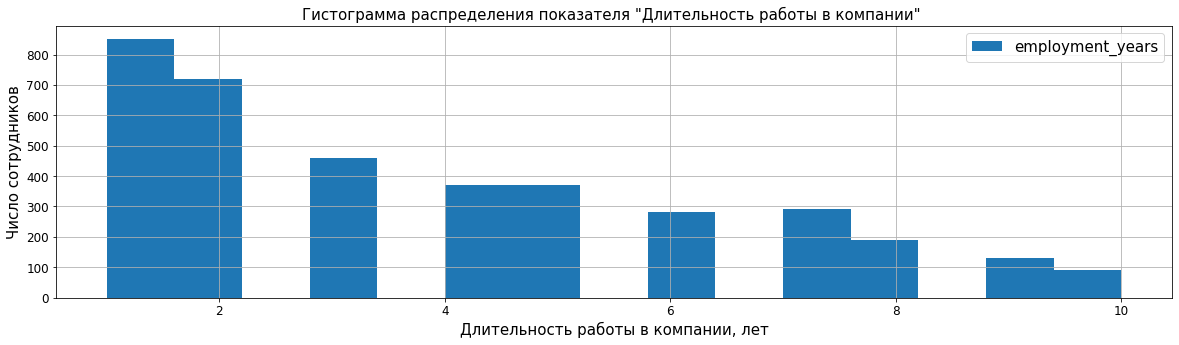

count    3755.000000
mean        3.817044
std         2.557142
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64


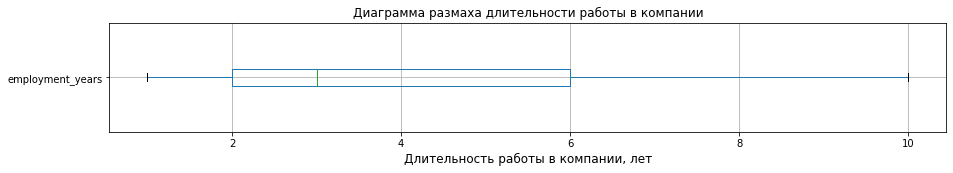

In [41]:
train_job['employment_years'].plot(kind = 'hist', bins = 15, figsize = (20, 5), grid = True, legend = True)
plt.title('Гистограмма распределения показателя "Длительность работы в компании" ', fontsize=15)
plt.xlabel('Длительность работы в компании, лет', fontsize = 15)
plt.ylabel('Число сотрудников', fontsize = 15)
plt.legend(fontsize = 15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

fig, ax = plt.subplots(figsize = (15,2))
ax = train_job[['employment_years']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха длительности работы в компании')
ax.set_xlabel('Длительность работы в компании, лет', fontsize = 12)

print(train_job['employment_years'].describe())

Средний срок работы в компании - 3 года. Больше всего сотрудников работают 1-2 года, но есть люди, работающие в компании по 4-5, 6-8 лет и меньше всего "долгожителе1", работающих по 9-10 лет. Обычное распределение сроков работы в компании

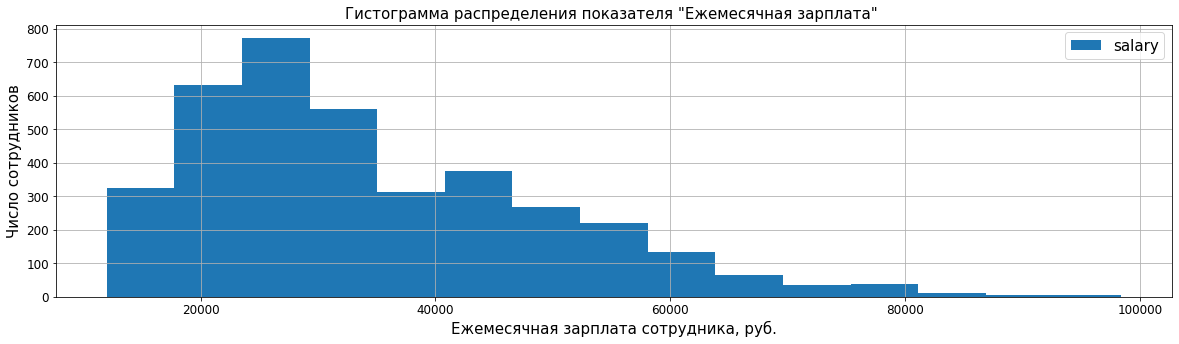

count     3755.000000
mean     34457.416778
std      15050.643870
min      12000.000000
25%      22800.000000
50%      31200.000000
75%      44400.000000
max      98400.000000
Name: salary, dtype: float64


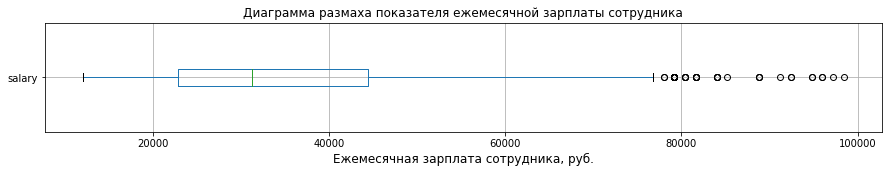

In [42]:
train_job['salary'].plot(kind = 'hist', bins = 15, figsize = (20, 5), grid = True, legend = True)
plt.title('Гистограмма распределения показателя "Ежемесячная зарплата" ', fontsize=15)
plt.xlabel('Ежемесячная зарплата сотрудника, руб.', fontsize = 15)
plt.ylabel('Число сотрудников', fontsize = 15)
plt.legend(fontsize = 15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

fig, ax = plt.subplots(figsize = (15,2))
ax = train_job[['salary']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха показателя ежемесячной зарплаты сотрудника')
ax.set_xlabel('Ежемесячная зарплата сотрудника, руб.', fontsize = 12)

print(train_job['salary'].describe())

Средняя зарпалата сотрудрников - 30 тыс.руб., второй по величине пик зарплат - около 45 тыс.руб., по логике это группа сотрудников среднего звена. И выше 70 тыс.руб. - это "выбросы", зарплаты сотрудников высшего звена, которых всегда ощутимо меньше остальных, поэтому нельзя назвать это аномалиями

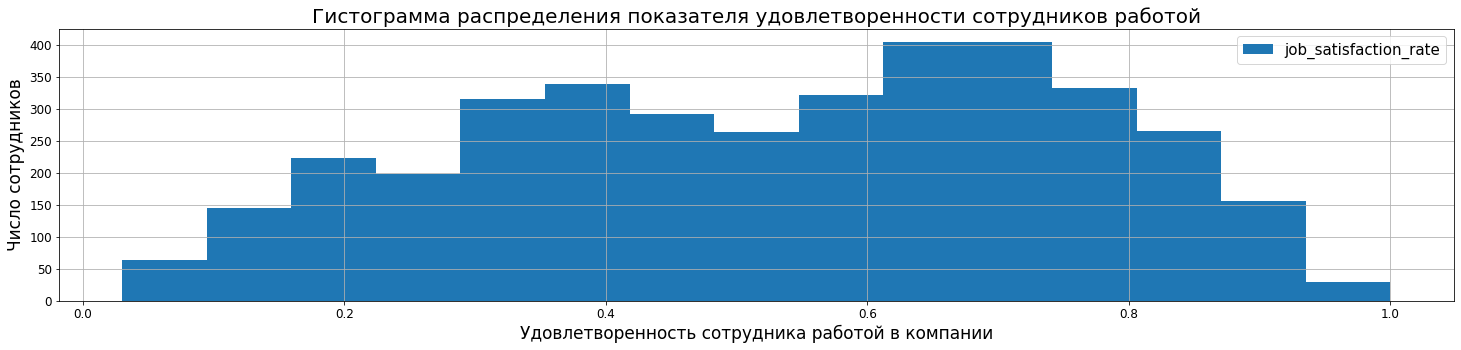

count    3755.000000
mean        0.532554
std         0.226393
min         0.030000
25%         0.350000
50%         0.550000
75%         0.710000
max         1.000000
Name: job_satisfaction_rate, dtype: float64


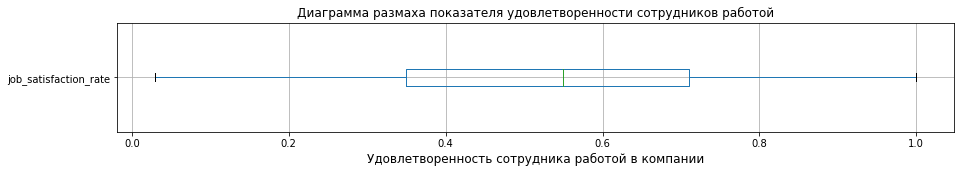

In [43]:
train_job['job_satisfaction_rate'].plot(kind = 'hist', bins = 15, figsize = (25, 5), grid = True, legend = True)
plt.title('Гистограмма распределения показателя удовлетворенности сотрудников работой', fontsize=20)
plt.xlabel('Удовлетворенность сотрудника работой в компании', fontsize = 17)
plt.ylabel('Число сотрудников', fontsize = 17)
plt.legend(fontsize = 15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

fig, ax = plt.subplots(figsize = (15,2))
ax = train_job[['job_satisfaction_rate']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха показателя удовлетворенности сотрудников работой')
ax.set_xlabel('Удовлетворенность сотрудника работой в компании', fontsize = 12)

print(train_job['job_satisfaction_rate'].describe())

На гистограмме распределения признака удовлетворенности работой в компании 2 пика: 40% (около 350 сотрудников) и 70% (около 450 сотрудников), среднее медианное значение - 56%

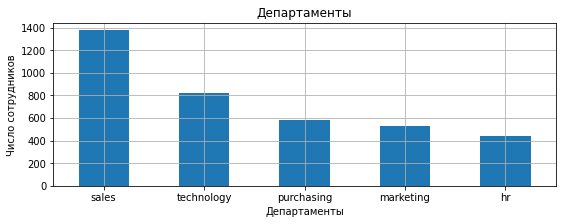

In [44]:
train_job['dept'].value_counts().plot(kind='bar', figsize = (9, 3),\
                                                             title = 'Департаменты',\
                                                             xlabel='Департаменты', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

37,8% сотрудников работают в отделе продаж, остальные почти равномерно распределены между другими отделами

In [45]:
train_job['dept'].value_counts()

sales         1374
technology     818
purchasing     586
marketing      531
hr             440
Name: dept, dtype: int64

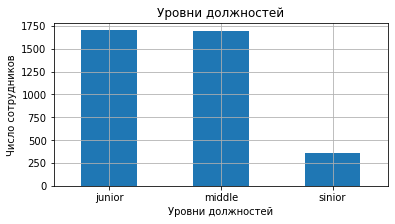

In [46]:
train_job['level'].value_counts().plot(kind='bar', figsize = (6, 3),\
                                                             title = 'Уровни должностей',\
                                                             xlabel='Уровни должностей', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [47]:
train_job['level'].value_counts()

junior    1699
middle    1695
sinior     357
Name: level, dtype: int64

Почти половина сотрудников компании имеют уровень junior, чуть меньше - уровень middle и 9% - уровень sinior

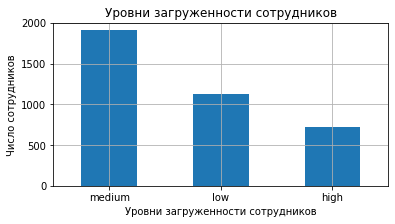

In [48]:
train_job['workload'].value_counts().plot(kind='bar', figsize = (6, 3),\
                                                             title = 'Уровни загруженности сотрудников',\
                                                             xlabel='Уровни загруженности сотрудников', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [49]:
train_job['workload'].value_counts()

medium    1908
low       1125
high       722
Name: workload, dtype: int64

Половина сотрудников имеют средний уровень загрузки, 30% - низкий и 20% - высокий

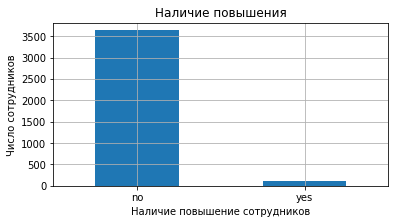

In [50]:
train_job['last_year_promo'].value_counts().plot(kind='bar', figsize = (6, 3),\
                                                             title = 'Наличие повышения',\
                                                             xlabel='Наличие повышение сотрудников', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [51]:
train_job['last_year_promo'].value_counts()

no     3635
yes     120
Name: last_year_promo, dtype: int64

Только 3% сотрудников получили повышение за последний год. Такое низкое число повышений может негативно влиять на мотивацию и удовлетворенность сотрудников работой

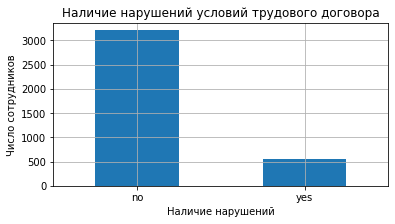

In [52]:
train_job['last_year_violations'].value_counts().plot(kind='bar', figsize = (6, 3),\
                                                             title = 'Наличие нарушений условий трудового договора',\
                                                             xlabel='Наличие нарушений', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [53]:
train_job['last_year_violations'].value_counts()

no     3202
yes     553
Name: last_year_violations, dtype: int64

14% сотрудников нарушали условия трудового договора за последний год

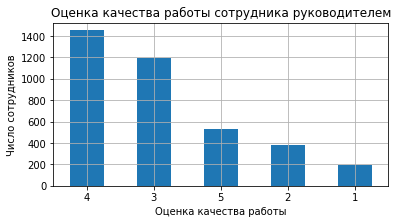

In [54]:
train_job['supervisor_evaluation'].value_counts().plot(kind='bar', figsize = (6, 3),\
                                                             title = 'Оценка качества работы сотрудника руководителем',\
                                                             xlabel='Оценка качества работы', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [55]:
train_job['supervisor_evaluation'].describe()

count    3755.000000
mean        3.463648
std         1.026265
min         1.000000
25%         3.000000
50%         4.000000
75%         4.000000
max         5.000000
Name: supervisor_evaluation, dtype: float64

Вывод по анализу данных:

Средняя ззрплата сотрудников - 30 тыс.руб., что объяснимо тем, что больше половины людей имеют уровень должности junior. Средний срок работы в компании - 3 года, бОльшая часть сотрудников работают в компании по 1-2 года. 37,8% людей работают в отделе продаж, половина сотрудников имеет среднй уровень загрузки. По всем данным никаких аномалий или особенностей не выявлено  

Единственный признак, вызывющий настороженность - очень небольшой процент повышений за последний год (3% сотрудников получили повышение), из чего можно сделать вывод, что это может плохо сказываться на мотивации и удовлетворенности работой

### Корреляционный анализ

In [56]:
display(train_job.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


In [57]:
train_job_phik = train_job[['job_satisfaction_rate', 'dept', 'level', 'workload',
                                    'employment_years', 'last_year_promo', 'last_year_violations',\
                                    'supervisor_evaluation', 'salary']]

corr_matrix_train_job = train_job_phik.phik_matrix(interval_cols = [
                                   'salary', 'job_satisfaction_rate']
                                    ) 
display(corr_matrix_train_job)

,job_satisfaction_rate,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
job_satisfaction_rate,1.000000,0.074739,0.077260,0.043958,0.319331,0.191464,0.566993,0.762964,0.149599
dept,0.074739,1.000000,0.000000,0.018079,0.025931,0.000000,0.000000,0.100579,0.270239
level,0.077260,0.000000,1.000000,0.404459,0.675467,0.100352,0.000000,0.000000,0.714411
workload,0.043958,0.018079,0.404459,1.000000,0.165879,0.057938,0.000000,0.037565,0.785277
employment_years,0.319331,0.025931,0.675467,0.165879,1.000000,0.180832,0.043766,0.000000,0.469992
last_year_promo,0.191464,0.000000,0.100352,0.057938,0.180832,1.000000,0.011274,0.016247,0.211173
last_year_violations,0.566993,0.000000,0.000000,0.000000,0.043766,0.011274,1.000000,0.183221,0.000000
supervisor_evaluation,0.762964,0.100579,0.000000,0.037565,0.000000,0.016247,0.183221,1.000000,0.000000
salary,0.149599,0.270239,0.714411,0.785277,0.469992,0.211173,0.000000,0.000000,1.000000


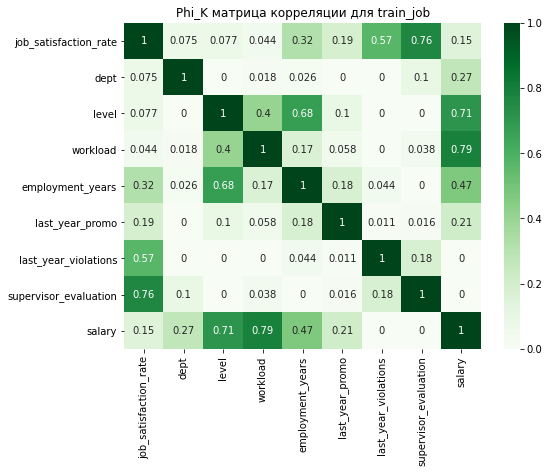

In [58]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_train_job, annot=True, cmap='Greens')
plt.title('Phi_K матрица корреляции для train_job')
plt.show()

Относительно высокая корреляцию видим у целевого признака с фактором оценки работы сотрудника руководством - 76%, ощутимая корреляция с числом нарушений трудового договора - 56%, т е сотрудники, нарушающие трудовой договор, закономерно имеют большие шансы на увольнение

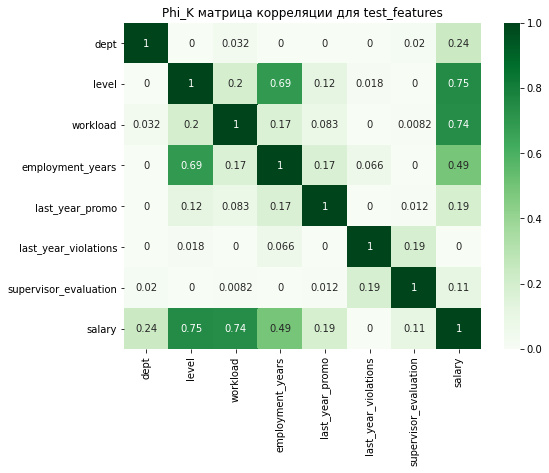

In [68]:
test_features_phik = test_features[['dept', 'level', 'workload',
                                    'employment_years', 'last_year_promo', 'last_year_violations',\
                                    'supervisor_evaluation', 'salary']]

corr_matrix_test_features = test_features_phik.phik_matrix(interval_cols = [
                                   'salary']
                                    ) 
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix_test_features, annot=True, cmap='Greens')
plt.title('Phi_K матрица корреляции для test_features')
plt.show()

## 4. Подготовка данных

In [69]:
X_train = train_job.drop(['job_satisfaction_rate'], axis=1)
y_train = train_job['job_satisfaction_rate']

X_test = test_features
y_test = test_target['job_satisfaction_rate']

In [70]:
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']

ord_columns = ['level', 'workload', 'supervisor_evaluation']

num_columns = ['employment_years', 'salary']

Добавляем OHE-кодирование в Пайплайн

1) Если в данных есть пропуски, заполним их самым часто встречающимся значением с помощью SimpleImputer. Назовём этот шаг simpleImputer_ohe

2) Кодируем данные с помощью OneHotEncoder. Назовём это шаг ohe

3) Объединим шаги в пайплайн и назовём его ohe_pipe

In [71]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore')
        )
    ]
) 

Добавляем Ordinal-кодирование в пайплайн.

1) simpleImputer_before_ord: Заполним пропуски самым часто встречающимся значением с помощью SimpleImputer. Пропуски есть только в столбце 'level': по уровню зарплаты (ниже среднего) в этих строках с пропусками можно сделать вывод, что эти сотрудники имеют должность junior, которая как раз является самым распространенным значением признака, поэтому в данном случае заполнение most_frequent будет корректно

2) ord: Проводим Ordinal-кодирование с помощью OrdinalEncoder

3) simpleImputer_after_ord: Заполним пропуски, которые появляются после Ordinal-кодирования

4) ord_pipe: Объединим все действия в пайплайн

In [72]:
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',  
            OrdinalEncoder(
                categories = [
                             ['junior', 'middle', 'sinior'],
                             ['low', 'medium', 'high'],
                             [1, 2, 3, 4, 5]
                            ],
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
) 

In [73]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
) 

Выводы по подготовке данных:

1) Количественные признаки employment_years, salary нужно отмасштабировать одним из скейлеров (Standard, Robust или MinMax) - какой из скейлеров использовать, определим при выборе лучшей модели. Можно предположить, что для признака salary больше подойдет RobustScaler, т к при масштабировании он учитывает выбросы и сохраняет структуру распределения данных.

2) Признак 'dept' (отдел) нужно кодировать OneHotEncoder - это не ранговый признак. OneHotEncoder использвуем для кодирования признака 'last_year_promo' (повышение) и 'last_year_violations' (наличие нарушений трудового договора), это бинарные признаки.

3) Признак 'level' кодируем с помощью OrdinalEncoder, т к значения признака можно ранжировать в порядке увеличения значимости: 'junior', 'middle', 'sinior'.

    Признак 'workload' (загруженность) тоже кодируем с помощью OrdinalEncoder, т к это ранговый признак,значения которого увеличиваются: 'low', 'medium', 'high'.

    Признак 'supervisor_evaluation' (оценка качества работы сотрудника) кодируем с помощью OrdinalEncoder, т к значения признака можно ранжировать в порядке увеличения значимости: 1, 2, 3, 4, 5.

4) Целевой признак кодировать и масштабировать не нужно, т к это количественный признак с непрерывным диапазоном значений [0, 1]

## 5. Обучение моделей

In [74]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeRegressor(random_state=RANDOM_STATE))
    ]
) 

Зададим метод масштабирования как гиперпараметр, чтобы перебирались методы StandardScaler(), RobustScaler() и MinMaxScaler(). Для автоматического подбора гиперпараметров будем использовать инструмент RandomizedSearchCV

В словаре укажем, какие варианты масштабирования собираемся перебрать: StandardScaler(), RobustScaler(), MinMaxScaler() и вариант без масштабирования.

Зададим в качестве гиперпараметра модели, которые хотим использовать: DecisionTreeRegressor(), LinearRegression()

In [75]:
param = [
    # словарь для модели DecisionTreeRegressor()
    {
        'models': [DecisionTreeRegressor(criterion = 'friedman_mse', random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 15), 
        'models__max_features': range(2, 15),
        'models__min_samples_split': range(2, 15),
        'models__min_samples_leaf': range(2, 15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
     # словарь для модели LogisticRegression()
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'] 
    }
]

Для оценки качества работы модели будем использовать метрику SMAPE («симметричное среднее абсолютное процентное отклонение»). Зададим функцию для расчета этой метрики

In [76]:
def smape(y_test, y_pred):
    numerator = np.abs(y_pred - y_test)
    denominator = (np.abs(y_test)+np.abs(y_pred))/2
    smape_value = np.mean(numerator/denominator)*100
    return smape_value
    
smape_metrics = make_scorer(smape, greater_is_better = False)

In [77]:
randomized_search = RandomizedSearchCV(
    pipe_final, 
    param_distributions=param, 
    scoring = smape_metrics,
    error_score= 'raise',
    n_iter=50,
    random_state=RANDOM_STATE, 
    n_jobs=-1
)
randomized_search.fit(X_train, y_train) 

RandomizedSearchCV(error_score='raise',
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore'))]),
                                                                               ['dept',
                                                                                'last_year_promo',
                                                                                'last_year_violations']),
                                                                              ('ord',
                                                                               Pipeline...
                                         'models__min_samples_leaf': range(2, 15),
                                         'models__min_samples_split': range(2, 15),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']},
                                        {'models': [LinearRegression()],
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']}],
                   random_state=42,
                   scoring=make_scorer(smape, greater_is_better=False, response_method='predict'))

In [79]:
results = randomized_search.cv_results_
results_df = pd.DataFrame(results)
top_10_results = results_df.sort_values(by='mean_test_score', ascending=False).head(10)
display(top_10_results[['params', 'mean_test_score', 'std_test_score']])

print('Метрика smape для лучшей модели:\n', randomized_search.best_score_)
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_) 

,params,mean_test_score,std_test_score
3,"{'preprocessor__num': StandardScaler(), 'model...",-15.720217,0.598788
48,"{'preprocessor__num': StandardScaler(), 'model...",-15.752411,0.741547
2,"{'preprocessor__num': RobustScaler(), 'models_...",-15.782340,0.730915
27,"{'preprocessor__num': MinMaxScaler(), 'models_...",-15.862637,0.502137
38,"{'preprocessor__num': RobustScaler(), 'models_...",-16.026082,0.504012
9,"{'preprocessor__num': RobustScaler(), 'models_...",-16.066425,0.693032
30,"{'preprocessor__num': StandardScaler(), 'model...",-16.106917,1.016227
10,"{'preprocessor__num': 'passthrough', 'models__...",-16.136430,0.907859
23,"{'preprocessor__num': 'passthrough', 'models__...",-16.425573,0.886182
24,"{'preprocessor__num': StandardScaler(), 'model...",-16.427962,0.885090


Метрика smape для лучшей модели:
 -15.720216885825687
Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleIm

In [81]:
y_test_pred = randomized_search.predict(X_test)
print('Метрика smape на тестовой выборке:', smape(y_test, y_test_pred))

Метрика smape на тестовой выборке: 14.088078338458338


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Вывод:

Мы обучили 2 модели: дерево решений и линейную регрессию, в качестве гипарпараметров использовали методы масштабирования, Для автоматического подбора гиперпараметров использовали инструмент RandomizedSearchCV.

Для оценки работы модели мы создали метрику SMAPE («симметричное среднее абсолютное процентное отклонение») По итогам подбора лучшей моделью стала модель DecisionTreeRegressor со следующими параметрами: criterion='friedman_mse', max_depth=14, max_features=9, min_samples_leaf=3, min_samples_split=9. Метрика SMAPE на тестовой выборке - 14,09%.

# Задача 2

## 1. Загрузка данных

In [82]:
train_quit = pd.read_csv('https://code.s3.yandex.net/datasets/train_quit.csv')

In [83]:
display(train_quit.head())

,id,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
0,723290,sales,middle,high,2,no,no,4,54000,no
1,814010,sales,junior,medium,2,no,no,4,27600,no
2,155091,purchasing,middle,medium,5,no,no,1,37200,no
3,257132,sales,junior,medium,2,no,yes,3,24000,yes
4,910140,marketing,junior,medium,2,no,no,5,25200,no


In [84]:
test_target_quit = pd.read_csv('https://code.s3.yandex.net/datasets/test_target_quit.csv')

In [85]:
display(test_target_quit.head())

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [86]:
display(test_features.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200
100480,marketing,junior,low,4,no,no,4,16800
100503,purchasing,middle,high,5,no,no,4,55200
100610,sales,middle,medium,5,no,no,4,43200
100692,sales,middle,high,6,no,no,4,48000


In [87]:
display(test_target_quit.head())

,id,quit
0,999029,yes
1,372846,no
2,726767,no
3,490105,no
4,416898,yes


In [88]:
test_target_quit = test_target_quit.sort_values(by = 'id')

In [89]:
display(test_target_quit.head())

,id,quit
1566,100298,no
491,100480,no
802,100503,no
725,100610,no
319,100692,no


In [90]:
train_quit = train_quit.set_index('id')
display(train_quit.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no
155091,purchasing,middle,medium,5,no,no,1,37200,no
257132,sales,junior,medium,2,no,yes,3,24000,yes
910140,marketing,junior,medium,2,no,no,5,25200,no


In [91]:
test_target_quit = test_target_quit.set_index('id')
display(test_target_quit.head())

,quit
id,
100298,no
100480,no
100503,no
100610,no
100692,no


## 2. Предобработка данных

In [92]:
train_quit.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4000 entries, 723290 to 853842
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   4000 non-null   object
 1   level                  4000 non-null   object
 2   workload               4000 non-null   object
 3   employment_years       4000 non-null   int64 
 4   last_year_promo        4000 non-null   object
 5   last_year_violations   4000 non-null   object
 6   supervisor_evaluation  4000 non-null   int64 
 7   salary                 4000 non-null   int64 
 8   quit                   4000 non-null   object
dtypes: int64(3), object(6)
memory usage: 312.5+ KB


In [93]:
test_target_quit.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 100298 to 999029
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   quit    2000 non-null   object
dtypes: object(1)
memory usage: 31.2+ KB


In [94]:
train_quit['dept'].unique()

array(['sales', 'purchasing', 'marketing', 'technology', 'hr'],
      dtype=object)

In [95]:
train_quit['level'].unique()

array(['middle', 'junior', 'sinior'], dtype=object)

In [96]:
train_quit['workload'].unique()

array(['high', 'medium', 'low'], dtype=object)

In [97]:
train_quit['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [98]:
train_quit['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

In [99]:
train_quit['supervisor_evaluation'].unique()

array([4, 1, 3, 5, 2])

In [100]:
train_quit.duplicated().sum()

1413

In [101]:
display(train_quit[train_quit.duplicated()])

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
873412,technology,junior,medium,2,no,no,4,31200,no
749683,sales,middle,low,8,no,no,4,19200,no
689526,marketing,middle,low,6,no,no,3,30000,no
786443,purchasing,middle,low,6,no,no,4,19200,no
362060,sales,junior,low,1,no,no,4,12000,yes
...,...,...,...,...,...,...,...,...,...
632886,sales,junior,low,3,no,no,4,12000,no
387733,marketing,middle,medium,5,no,no,3,44400,no
588809,sales,junior,medium,4,no,no,3,26400,no


Полные дуликаты, получившиеся после перемещения id в индекс, удаляем, т. к. полное совпадение всех признаков у разных строк может негативно с казаться на качестве обученной на такой выборке модели

In [102]:
train_quit = train_quit.drop_duplicates()
train_quit.duplicated().sum()

0

## 3. Исследовательский анализ данных

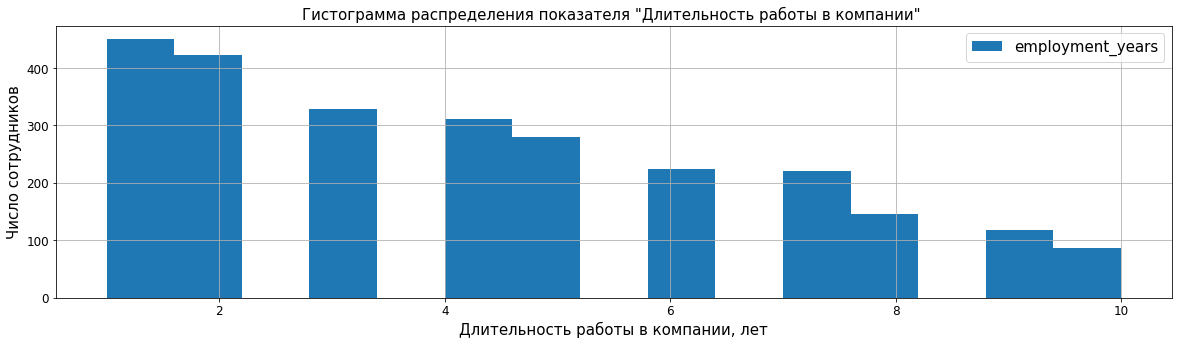

count    2587.000000
mean        4.213375
std         2.601105
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        10.000000
Name: employment_years, dtype: float64


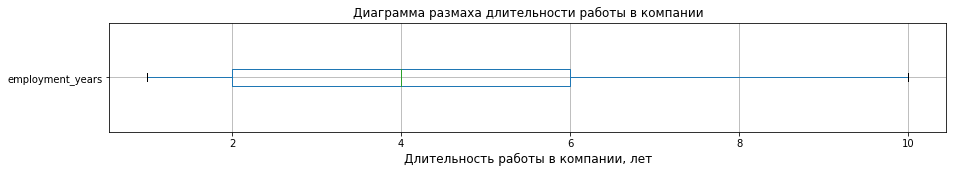

In [103]:
train_quit['employment_years'].plot(kind = 'hist', bins = 15, figsize = (20, 5), grid = True, legend = True)
plt.title('Гистограмма распределения показателя "Длительность работы в компании" ', fontsize=15)
plt.xlabel('Длительность работы в компании, лет', fontsize = 15)
plt.ylabel('Число сотрудников', fontsize = 15)
plt.legend(fontsize = 15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

fig, ax = plt.subplots(figsize = (15,2))
ax = train_quit[['employment_years']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха длительности работы в компании')
ax.set_xlabel('Длительность работы в компании, лет', fontsize = 12)

print(train_quit['employment_years'].describe())

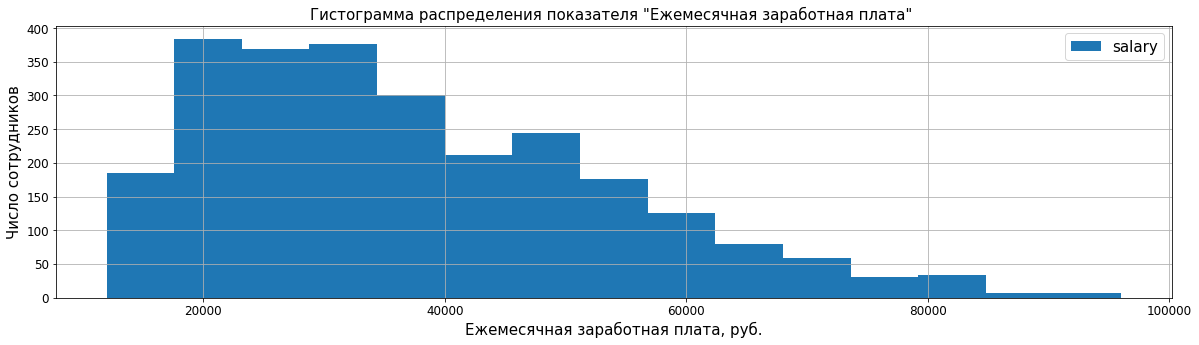

count     2587.000000
mean     37107.692308
std      16267.354906
min      12000.000000
25%      24000.000000
50%      33600.000000
75%      46800.000000
max      96000.000000
Name: salary, dtype: float64


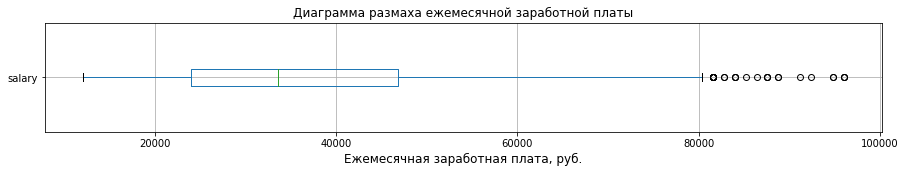

In [104]:
train_quit['salary'].plot(kind = 'hist', bins = 15, figsize = (20, 5), grid = True, legend = True)
plt.title('Гистограмма распределения показателя "Ежемесячная заработная плата" ', fontsize=15)
plt.xlabel('Ежемесячная заработная плата, руб.', fontsize = 15)
plt.ylabel('Число сотрудников', fontsize = 15)
plt.legend(fontsize = 15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

fig, ax = plt.subplots(figsize = (15,2))
ax = train_quit[['salary']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха ежемесячной заработной платы')
ax.set_xlabel('Ежемесячная заработная плата, руб.', fontsize = 12)

print(train_quit['salary'].describe())

Переходим к анализу категориальных признаков. Построим столбчатые диаграммы для показателей:

dept  
level  
workload  
last_year_promo  
last_year_violations  
supervisor_evaluation  
quit (целевой)

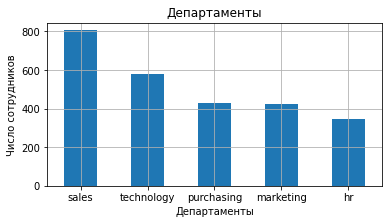

In [105]:
train_quit['dept'].value_counts().plot(kind='bar', figsize = (6, 3), \
                                                             title = 'Департаменты',\
                                                             xlabel='Департаменты', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [106]:
train_quit['dept'].value_counts()

sales         805
technology    581
purchasing    430
marketing     423
hr            348
Name: dept, dtype: int64

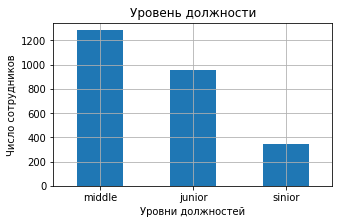

In [107]:
train_quit['level'].value_counts().plot(kind='bar', figsize = (5, 3),\
                                                             title = 'Уровень должности',\
                                                             xlabel='Уровни должностей', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [108]:
train_quit['level'].value_counts()

middle    1282
junior     958
sinior     347
Name: level, dtype: int64

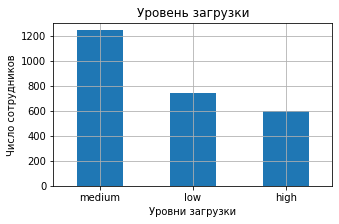

In [109]:
train_quit['workload'].value_counts().plot(kind='bar', figsize = (5, 3),\
                                                             title = 'Уровень загрузки',\
                                                             xlabel='Уровни загрузки', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [110]:
train_quit['workload'].value_counts()

medium    1244
low        746
high       597
Name: workload, dtype: int64

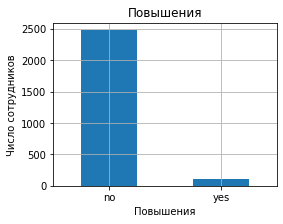

In [111]:
train_quit['last_year_promo'].value_counts().plot(kind='bar', figsize = (4, 3),\
                                                             title = 'Повышения',\
                                                             xlabel='Повышения', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [112]:
train_quit['last_year_promo'].value_counts()

no     2476
yes     111
Name: last_year_promo, dtype: int64

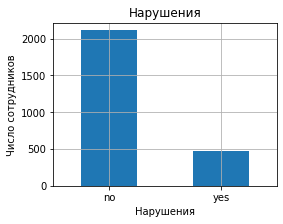

In [113]:
train_quit['last_year_violations'].value_counts().plot(kind='bar', figsize = (4, 3),\
                                                             title = 'Нарушения',\
                                                             xlabel='Нарушения', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [114]:
train_quit['last_year_violations'].value_counts()

no     2111
yes     476
Name: last_year_violations, dtype: int64

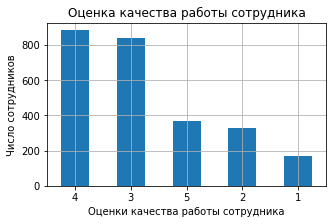

In [115]:
train_quit['supervisor_evaluation'].value_counts().plot(kind='bar', figsize = (5, 3),\
                                                             title = 'Оценка качества работы сотрудника',\
                                                             xlabel='Оценки качества работы сотрудника', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [116]:
train_quit['supervisor_evaluation'].value_counts()

4    882
3    839
5    369
2    326
1    171
Name: supervisor_evaluation, dtype: int64

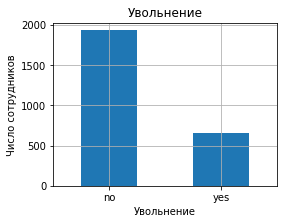

In [117]:
train_quit['quit'].value_counts().plot(kind='bar', figsize = (4, 3),\
                                                             title = 'Увольнение',\
                                                             xlabel='Увольнение', \
                                                             ylabel='Число сотрудников', grid = True, rot=0);

In [118]:
train_quit['quit'].value_counts()

no     1932
yes     655
Name: quit, dtype: int64

Распределения значений признаков очень похоже с распределением признаков в первой задаче.

Для построения "портрета уволившегося сотрудника" разделим таблицу train_quit на две части: в одной будут уволившиеся сотрудники, в другой - оставшиеся

In [119]:
train_quit_stable = train_quit.loc[train_quit['quit'] == 'no']

In [120]:
display(train_quit_stable.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no
155091,purchasing,middle,medium,5,no,no,1,37200,no
910140,marketing,junior,medium,2,no,no,5,25200,no
417070,technology,middle,medium,8,no,no,2,44400,no


In [121]:
train_quit_retired = train_quit.loc[train_quit['quit'] == 'yes']

In [122]:
display(train_quit_retired.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
257132,sales,junior,medium,2,no,yes,3,24000,yes
699916,sales,junior,low,1,no,yes,3,18000,yes
613206,technology,middle,medium,2,no,no,3,45600,yes
468145,technology,junior,medium,2,no,no,3,30000,yes
982346,marketing,junior,medium,3,no,no,3,30000,yes


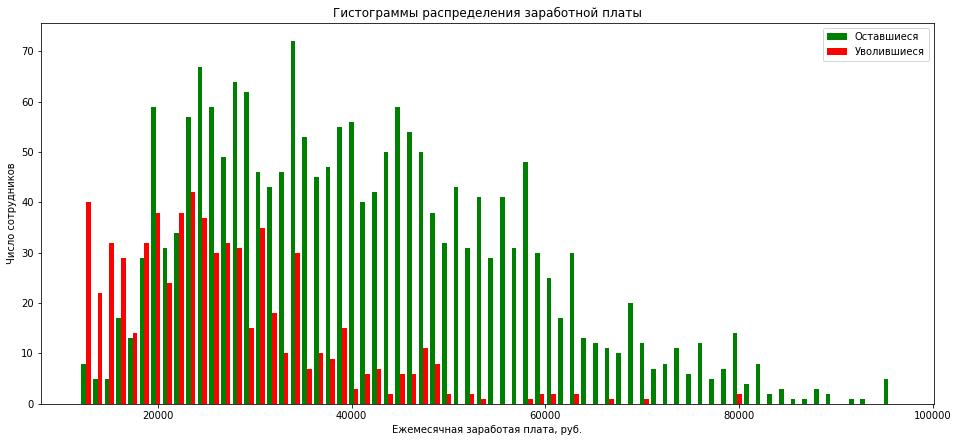

In [123]:
x1 = list(train_quit_stable['salary'])
x2 = list(train_quit_retired['salary'])

colors = ['green', 'red']
names = ['Оставшиеся', 'Уволившиеся']

k = plt.figure()
k.set_figwidth(16)
k.set_figheight(7)
plt.hist([x1, x2], bins = 70,
         color = colors, label=names)

plt.legend()
plt.title('Гистограммы распределения заработной платы')
plt.xlabel('Ежемесячная заработая плата, руб.')
plt.ylabel('Число сотрудников')
plt.show()

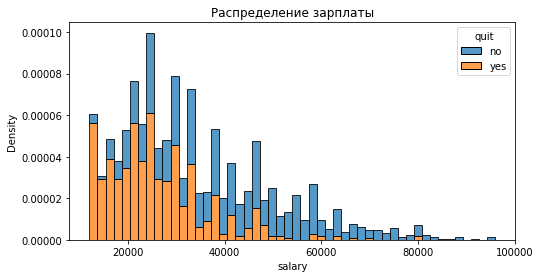

In [124]:
plt.figure(figsize=(8, 4))
sns.histplot(data=train_quit, 
             x="salary", 
             bins=50, 
             hue="quit", 
             multiple="stack",
             stat='density', 
             common_norm=False).set(title='Распределение зарплаты');

count     1932.000000
mean     40952.173913
std      16085.739667
min      12000.000000
25%      27600.000000
50%      39000.000000
75%      51600.000000
max      96000.000000
Name: salary, dtype: float64


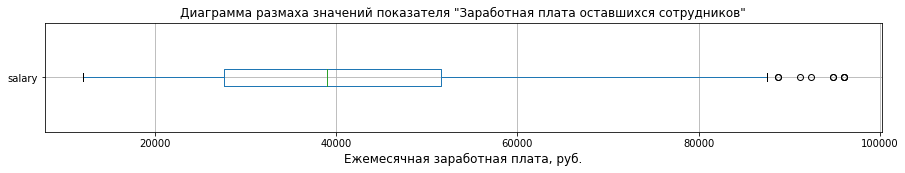

In [125]:
fig, ax = plt.subplots(figsize = (15,2))
ax = train_quit_stable[['salary']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений показателя "Заработная плата оставшихся сотрудников"')
ax.set_xlabel('Ежемесячная заработная плата, руб.', fontsize = 12)

print(train_quit_stable['salary'].describe())

count      655.000000
mean     25767.938931
std      10484.828614
min      12000.000000
25%      18000.000000
50%      24000.000000
75%      30600.000000
max      79200.000000
Name: salary, dtype: float64


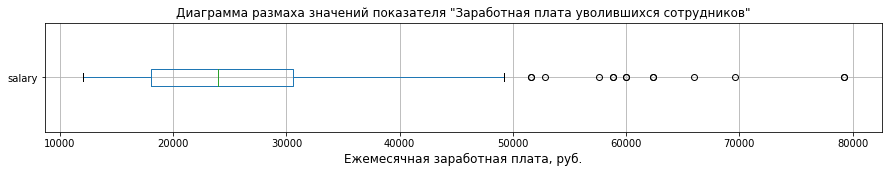

In [126]:
fig, ax = plt.subplots(figsize = (15,2))
ax = train_quit_retired[['salary']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений показателя "Заработная плата уволившихся сотрудников"')
ax.set_xlabel('Ежемесячная заработная плата, руб.', fontsize = 12)

print(train_quit_retired['salary'].describe())

Глядя на гистограммы и диаграммы размаха признака "Заработная плата сотрудников" можно сделать выводы:

1) Больше всего увольнений у сотрудников с зарплатой около 10 тыс. руб. (самый высокий пик на гистограмме). Скорее всего, это персонал, нанятый на полставки или меньше для выполнения сопутствующих работ вроде курьерской доставки, уборки, обсуживания помещений. Средняя зарплата уволившихся сотрудников - 23 тыс.руб, три четверти уволившихся сотрудников имели зарплаты до 27,6 тыc.руб. Есть единичные случаи увольнения сотрудников со средними зарплатами

2) Средняя зп оставшихся сотрудников - 35 тыс.руб., три четверти уволившихся сотрудников имели зарплаты до 48 тыс.руб. Сорудники с зарплатой более 80 тыс. не увольняются

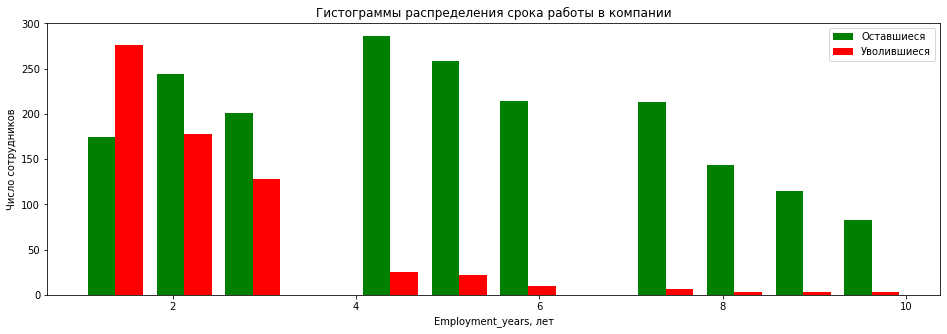

In [127]:
x1 = list(train_quit_stable['employment_years'])
x2 = list(train_quit_retired['employment_years'])

colors = ['green', 'red']
names = ['Оставшиеся', 'Уволившиеся']

k = plt.figure()
k.set_figwidth(16)
k.set_figheight(5)
plt.hist([x1, x2], bins = 12,
         color = colors, label=names),
plt.legend()
plt.title('Гистограммы распределения срока работы в компании')
plt.xlabel('Employment_years, лет')
plt.ylabel('Число сотрудников')
plt.show();

count    1932.000000
mean        4.908903
std         2.527730
min         1.000000
25%         3.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: employment_years, dtype: float64


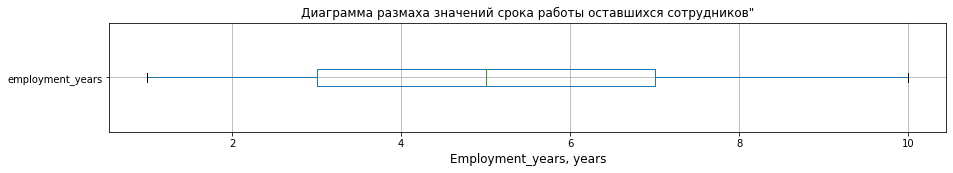

In [128]:
fig, ax = plt.subplots(figsize = (15,2))
ax = train_quit_stable[['employment_years']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений срока работы оставшихся сотрудников"')
ax.set_xlabel('Employment_years, years', fontsize = 12)

print(train_quit_stable['employment_years'].describe())

count    655.000000
mean       2.161832
std        1.497626
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       10.000000
Name: employment_years, dtype: float64


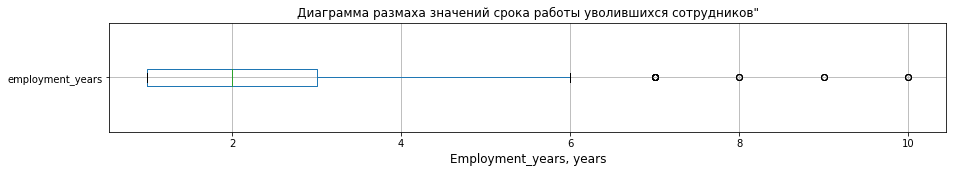

In [129]:
fig, ax = plt.subplots(figsize = (15,2))
ax = train_quit_retired[['employment_years']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений срока работы уволившихся сотрудников"')
ax.set_xlabel('Employment_years, years', fontsize = 12)

print(train_quit_retired['employment_years'].describe())

Вывод по анализу признака "Срок работы в компании":

Больше всего увольнений - у сотрудников со сроком работы 1 год, три четверти уволившихся сорудников работали в компании менее 2 лет. Увольнения сотрудников сроком работы более 4 лет единичны

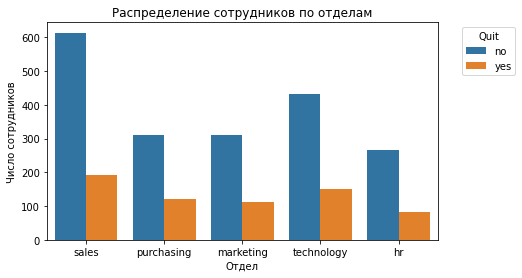

dept        quit
hr          no      0.764368
            yes     0.235632
marketing   no      0.735225
            yes     0.264775
purchasing  no      0.720930
            yes     0.279070
sales       no      0.762733
            yes     0.237267
technology  no      0.741824
            yes     0.258176
Name: quit, dtype: float64


In [130]:
plt.figure(figsize=(7, 4))
sns.countplot(x = 'dept', hue = 'quit', data = train_quit)
plt.xlabel('Отдел')
plt.ylabel('Число сотрудников')
plt.title('Распределение сотрудников по отделам')
plt.legend(title='Quit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
print(train_quit.groupby(['dept'])['quit'].value_counts(normalize=True))

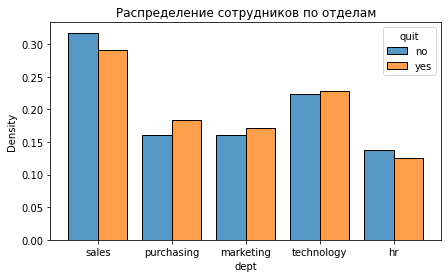

In [131]:
plt.figure(figsize=(7, 4))
sns.histplot(data=train_quit, 
             x="dept",  
             hue="quit", 
             multiple="dodge",
             shrink = .8,
             stat='density', 
             common_norm=False).set(title='Распределение сотрудников по отделам');

Чаще всего увольняются сотрудники из отдела продаж (около 28% увольняющихся сотрудников), чуть меньше - из отдела 'technology' (23% увольняющихся). Сотрудники отделов закупок, маркетинга увольняются меньше

In [132]:
display(train_quit_stable['workload'].value_counts())

medium    989
high      488
low       455
Name: workload, dtype: int64

In [133]:
display(train_quit_retired['workload'].value_counts())

low       291
medium    255
high      109
Name: workload, dtype: int64

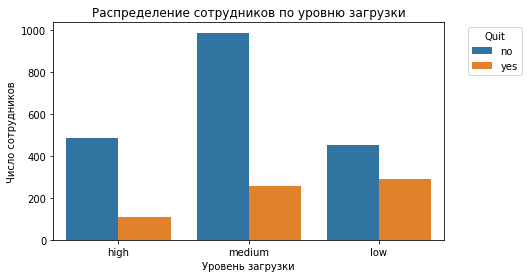

workload  quit
high      no      0.817420
          yes     0.182580
low       no      0.609920
          yes     0.390080
medium    no      0.795016
          yes     0.204984
Name: quit, dtype: float64


In [134]:
plt.figure(figsize=(7, 4))
sns.countplot(x = 'workload', hue = 'quit', data = train_quit)
plt.xlabel('Уровень загрузки')
plt.ylabel('Число сотрудников')
plt.title('Распределение сотрудников по уровню загрузки')
plt.legend(title='Quit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
print(train_quit.groupby(['workload'])['quit'].value_counts(normalize=True))

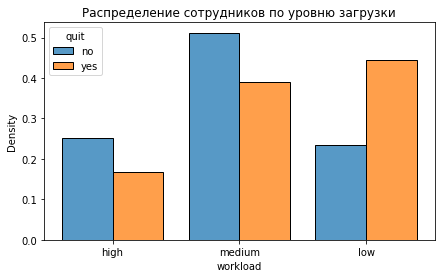

In [135]:
plt.figure(figsize=(7, 4))
sns.histplot(data=train_quit, 
             x="workload",  
             hue="quit", 
             multiple="dodge",
             shrink = .8,
             stat='density', 
             common_norm=False).set(title='Распределение сотрудников по уровню загрузки');

45% увольняющихся сотрудников имели низкий уровень загрузки, 40% увольняющихся сотрудников имели средний уровень загрузки и 15% уволившихся сотрудников имели высокий уровень загрузки

In [136]:
display(train_quit_stable['last_year_promo'].value_counts())

no     1822
yes     110
Name: last_year_promo, dtype: int64

In [137]:
display(train_quit_retired['last_year_promo'].value_counts())

no     654
yes      1
Name: last_year_promo, dtype: int64

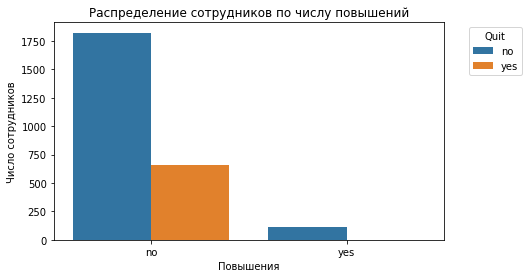

last_year_promo  quit
no               no      0.735864
                 yes     0.264136
yes              no      0.990991
                 yes     0.009009
Name: quit, dtype: float64


In [138]:
plt.figure(figsize=(7, 4))
sns.countplot(x = 'last_year_promo', hue = 'quit', data = train_quit)
plt.xlabel('Повышения')
plt.ylabel('Число сотрудников')
plt.title('Распределение сотрудников по числу повышений')
plt.legend(title='Quit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
print(train_quit.groupby(['last_year_promo'])['quit'].value_counts(normalize=True))

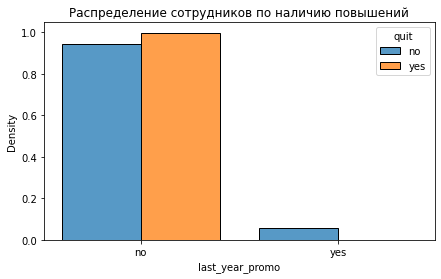

In [139]:
plt.figure(figsize=(7, 4))
sns.histplot(data=train_quit, 
             x="last_year_promo",  
             hue="quit", 
             multiple="dodge",
             shrink = .8,
             stat='density', 
             common_norm=False).set(title='Распределение сотрудников по наличию повышений');

100% уволившихся сотрудников не получили повышения за последний год. Сотрудники, получившие повышение, не увольняются (за весь период уволился только 1 сорудник с повышением)

In [140]:
display(train_quit_stable['last_year_violations'].value_counts())

no     1636
yes     296
Name: last_year_violations, dtype: int64

In [141]:
display(train_quit_retired['last_year_violations'].value_counts())

no     475
yes    180
Name: last_year_violations, dtype: int64

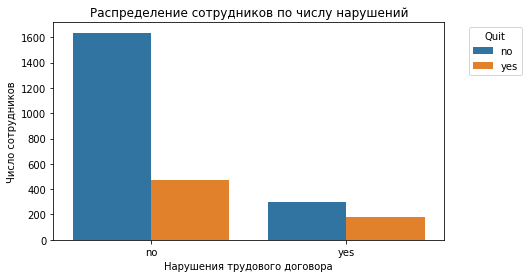

last_year_violations  quit
no                    no      0.774988
                      yes     0.225012
yes                   no      0.621849
                      yes     0.378151
Name: quit, dtype: float64


In [142]:
plt.figure(figsize=(7, 4))
sns.countplot(x = 'last_year_violations', hue = 'quit', data = train_quit)
plt.xlabel('Нарушения трудового договора')
plt.ylabel('Число сотрудников')
plt.title('Распределение сотрудников по числу нарушений')
plt.legend(title='Quit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
print(train_quit.groupby(['last_year_violations'])['quit'].value_counts(normalize=True))

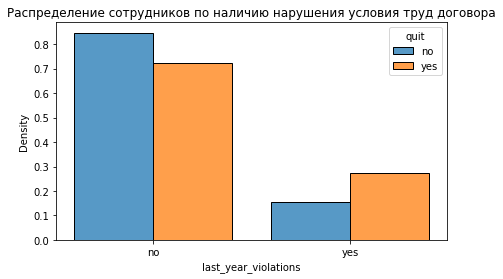

In [143]:
plt.figure(figsize=(7, 4))
sns.histplot(data=train_quit, 
             x="last_year_violations",  
             hue="quit", 
             multiple="dodge",
             shrink = .8,
             stat='density', 
             common_norm=False).set(title='Распределение сотрудников по наличию нарушения условия труд договора');

30% уволившихся сотрудников допускали нарушение условий трудового договора. Среди тех, кто не нарушает условия трудового договора, увольняются 15%

In [144]:
display(train_quit_stable['supervisor_evaluation'].value_counts())

4    734
3    567
5    326
2    203
1    102
Name: supervisor_evaluation, dtype: int64

In [145]:
display(train_quit_retired['supervisor_evaluation'].value_counts())

3    272
4    148
2    123
1     69
5     43
Name: supervisor_evaluation, dtype: int64

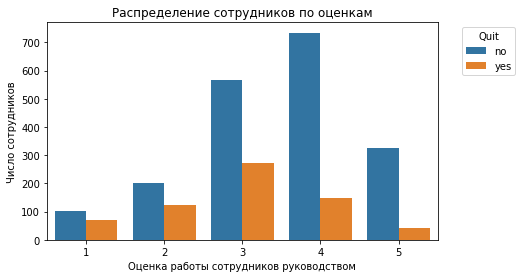

supervisor_evaluation  quit
1                      no      0.596491
                       yes     0.403509
2                      no      0.622699
                       yes     0.377301
3                      no      0.675805
                       yes     0.324195
4                      no      0.832200
                       yes     0.167800
5                      no      0.883469
                       yes     0.116531
Name: quit, dtype: float64


In [146]:
plt.figure(figsize=(7, 4))
sns.countplot(x = 'supervisor_evaluation', hue = 'quit', data = train_quit)
plt.xlabel('Оценка работы сотрудников руководством')
plt.ylabel('Число сотрудников')
plt.title('Распределение сотрудников по оценкам')
plt.legend(title='Quit', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
print(train_quit.groupby(['supervisor_evaluation'])['quit'].value_counts(normalize=True))

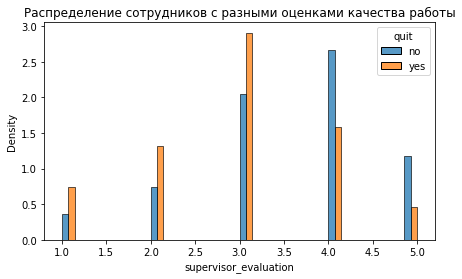

In [147]:
plt.figure(figsize=(7, 4))
sns.histplot(data=train_quit, 
             x="supervisor_evaluation",  
             hue="quit", 
             multiple="dodge",
             shrink = 1,
             stat='density', 
             common_norm=False).set(title='Распределение сотрудников с разными оценками качества работы');

Больше всего в абсолютном выражении увольняются сотрудники, получившие среднюю оценку за работу. В относительном выражении больше всего увольняются сотрудники, получишие минимальную оценку (47%) и плохую оценку (42%)

Портрет уволившегося сотрудника:

Среднестатистический уволившийся сотрудник имеет зарплату 23 тыс.руб., работает в компании 1 год (реже 2), работал в отделе продаж или технологий, имел низкий уровень загрузки, не получал повышений за последний маесяц, каждый 2ой-3-й уволившийся сотрудник допускал нарушения трудового договора и среднюю оценку начальства за качества работы

In [148]:
display(test_target_quit.head())

,quit
id,
100298,no
100480,no
100503,no
100610,no
100692,no


In [149]:
display(test_target.head())

,job_satisfaction_rate
id,
100298,0.80
100480,0.84
100503,0.79
100610,0.75
100692,0.69


Строки расположены в одинаковом порядке, объединяем таблицы

In [150]:
target_both = pd.merge(test_target, test_target_quit, on = 'id', how = 'outer')
display(target_both.tail())

,job_satisfaction_rate,quit
id,,
997290,0.79,no
998548,0.76,yes
998762,0.48,yes
998900,0.57,no
999029,0.35,yes


In [151]:
#список значений признака job_satisfaction_rate оставшихся сотрудников
x1 = list(target_both[target_both['quit'] == 'no']['job_satisfaction_rate'])

#список значений признака job_satisfaction_rate уволившихся сотрудников
x2 = list(target_both[target_both['quit'] == 'yes']['job_satisfaction_rate'])

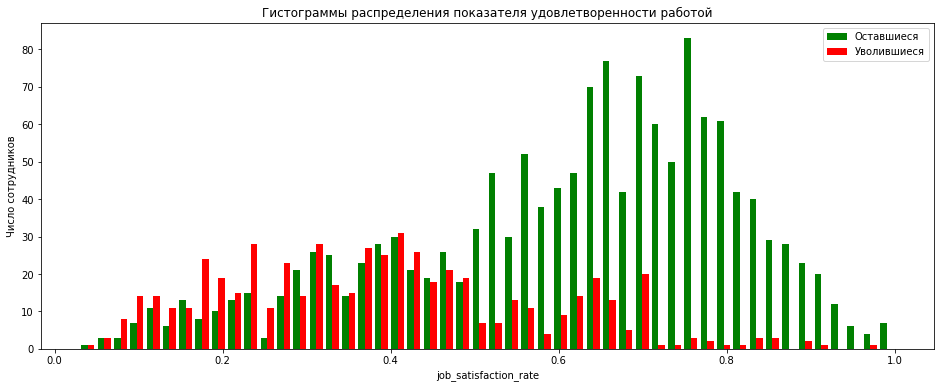

In [152]:
colors = ['green', 'red']
names = ['Оставшиеся', 'Уволившиеся']

k = plt.figure()
k.set_figwidth(16)
k.set_figheight(6)
plt.hist([x1, x2], bins = 50,
         color = colors, label=names)

plt.legend()
plt.title('Гистограммы распределения показателя удовлетворенности работой')
plt.xlabel('job_satisfaction_rate')
plt.ylabel('Число сотрудников')
plt.show();

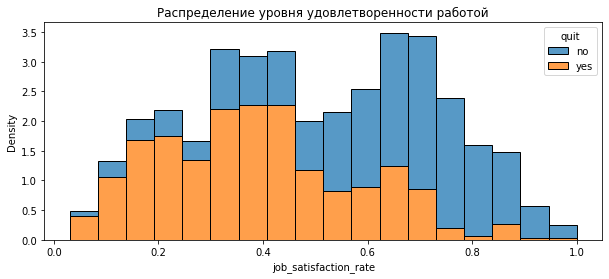

In [153]:
plt.figure(figsize=(10, 4))
sns.histplot(data=target_both, 
             x="job_satisfaction_rate",  
             hue="quit", 
             multiple="stack",
             stat='density', 
             common_norm=False).set(title='Распределение уровня удовлетворенности работой');

In [154]:
stable = target_both[target_both['quit'] == 'no']
retired = target_both[target_both['quit'] == 'yes']

In [155]:
display(stable.head())

,job_satisfaction_rate,quit
id,,
100298,0.80,no
100480,0.84,no
100503,0.79,no
100610,0.75,no
100692,0.69,no


count    1436.000000
mean        0.612040
std         0.199367
min         0.030000
25%         0.500000
50%         0.660000
75%         0.760000
max         1.000000
Name: job_satisfaction_rate, dtype: float64


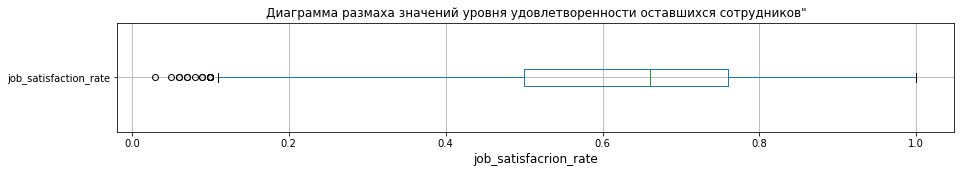

In [156]:
fig, ax = plt.subplots(figsize = (15,2))
ax = stable[['job_satisfaction_rate']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений уровня удовлетворенности оставшихся сотрудников"')
ax.set_xlabel('job_satisfacrion_rate', fontsize = 12)

print(stable['job_satisfaction_rate'].describe())

count    564.000000
mean       0.387713
std        0.185784
min        0.040000
25%        0.240000
50%        0.370000
75%        0.492500
max        0.970000
Name: job_satisfaction_rate, dtype: float64


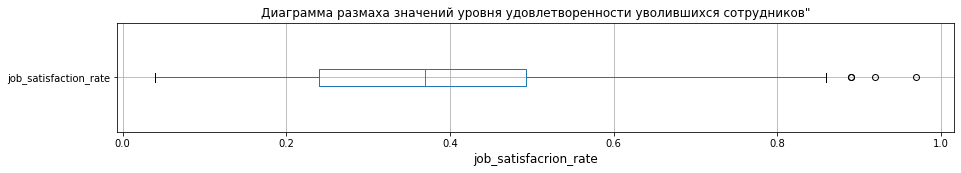

In [157]:
fig, ax = plt.subplots(figsize = (15,2))
ax = retired[['job_satisfaction_rate']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений уровня удовлетворенности уволившихся сотрудников"')
ax.set_xlabel('job_satisfacrion_rate', fontsize = 12)

print(retired['job_satisfaction_rate'].describe())

На гистограммах и диаграммах рахмаха отчетливо видна корреляция между вровнем удовлетворенности и вероятностью увольнения сотрудников: средний job_satisfaction_rate оставшихся сотрудников равен 66%, 3/4 сотрудников имеют job_satisfaction_rate не ниже 76%. В то время как средний job_satisfaction_rate уволившихся сотрудников равен 37%, 3/4 сотрудников имеют job_satisfaction_rate не ниже 49%

## 4. Добавление нового входного признака

In [158]:
display(train_quit.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no
155091,purchasing,middle,medium,5,no,no,1,37200,no
257132,sales,junior,medium,2,no,yes,3,24000,yes
910140,marketing,junior,medium,2,no,no,5,25200,no


Уберем признак quit, т к его не было во входных признаках модели из перой задачи

In [159]:
train_quit_correct = train_quit.drop(['quit'], axis=1)
display(train_quit_correct.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000
814010,sales,junior,medium,2,no,no,4,27600
155091,purchasing,middle,medium,5,no,no,1,37200
257132,sales,junior,medium,2,no,yes,3,24000
910140,marketing,junior,medium,2,no,no,5,25200


In [160]:
job_satisf_pred = randomized_search.predict(train_quit_correct)

In [161]:
train_quit_correct['job_satisf_rate_pred'] = job_satisf_pred
train_quit_new = train_quit_correct
display(train_quit_new.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisf_rate_pred
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,0.635385
814010,sales,junior,medium,2,no,no,4,27600,0.843158
155091,purchasing,middle,medium,5,no,no,1,37200,0.326667
257132,sales,junior,medium,2,no,yes,3,24000,0.333333
910140,marketing,junior,medium,2,no,no,5,25200,0.845000


Добавим признак job_satisfaction_rate, предсказанный лучшей моделью первой задачи, к входным признакам тестовой выборки второй задачи. Подготовим данные satisf_test_features для прогноза

In [162]:
display(test_features.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200
100480,marketing,junior,low,4,no,no,4,16800
100503,purchasing,middle,high,5,no,no,4,55200
100610,sales,middle,medium,5,no,no,4,43200
100692,sales,middle,high,6,no,no,4,48000


In [163]:
job_satisf_pred_test = randomized_search.predict(test_features)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [164]:
test_features['job_satisf_rate_pred'] = job_satisf_pred_test
test_features_new = test_features
display(test_features_new.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisf_rate_pred
id,,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200,0.852500
100480,marketing,junior,low,4,no,no,4,16800,0.841667
100503,purchasing,middle,high,5,no,no,4,55200,0.791765
100610,sales,middle,medium,5,no,no,4,43200,0.835000
100692,sales,middle,high,6,no,no,4,48000,0.679565


В тренировочную выборку train_quit добавили прогноз job_satisfaction_rate, полученный с помощью лучшей модели первой задачи, рассчитанный на данных из train_quit

**Шаг 5. Подготовка данных**

In [165]:
display(test_features_new.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisf_rate_pred
id,,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200,0.852500
100480,marketing,junior,low,4,no,no,4,16800,0.841667
100503,purchasing,middle,high,5,no,no,4,55200,0.791765
100610,sales,middle,medium,5,no,no,4,43200,0.835000
100692,sales,middle,high,6,no,no,4,48000,0.679565


In [166]:
display(test_target_quit.head())

,quit
id,
100298,no
100480,no
100503,no
100610,no
100692,no


Строки в тестовой выборке входных признаков и тестовой выборке целевого признака расположены в одинаковом порядке, id совпадают

In [167]:
display(train_quit_new.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisf_rate_pred
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,0.635385
814010,sales,junior,medium,2,no,no,4,27600,0.843158
155091,purchasing,middle,medium,5,no,no,1,37200,0.326667
257132,sales,junior,medium,2,no,yes,3,24000,0.333333
910140,marketing,junior,medium,2,no,no,5,25200,0.845000


In [168]:
display(test_features_new.head())

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisf_rate_pred
id,,,,,,,,,
100298,hr,junior,low,2,no,no,4,19200,0.852500
100480,marketing,junior,low,4,no,no,4,16800,0.841667
100503,purchasing,middle,high,5,no,no,4,55200,0.791765
100610,sales,middle,medium,5,no,no,4,43200,0.835000
100692,sales,middle,high,6,no,no,4,48000,0.679565


In [169]:
display(test_target_quit.head())

,quit
id,
100298,no
100480,no
100503,no
100610,no
100692,no


## 5. Подготовка данных

In [170]:
X_train_ = train_quit_new
y_train_ = train_quit['quit']

X_test_ = test_features_new
y_test_ = test_target_quit['quit']

In [171]:
label_encoder = LabelEncoder()
label_encoder.fit(y_train_)

y_train_ = label_encoder.transform(y_train_)
y_test_ = label_encoder.transform(y_test_) 

In [172]:
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations']

ord_columns = ['level', 'workload', 'supervisor_evaluation']

num_columns = ['employment_years', 'salary', 'job_satisf_rate_pred']

In [173]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore')
        )
    ]
) 

In [174]:
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',  
            OrdinalEncoder(
                categories = [
                             ['junior', 'middle', 'sinior'],
                             ['low', 'medium', 'high'],
                             [1, 2, 3, 4, 5]
                            ],
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
) 

In [175]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
) 

## 6. Обучение модели

In [176]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
) 

Зададим метод масштабирования как гиперпараметр, чтобы перебирались методы StandardScaler(), RobustScaler() и MinMaxScaler(). Для автоматического подбора гиперпараметров буду использовать инструмент RandomizedSearchCV.

В словаре укажем, какие варианты масштабирования собираемся перебрать: StandardScaler(), RobustScaler(), MinMaxScaler() и вариант без масштабирования.

Зададим в качестве гиперпараметра модели, которые хотим использовать: DecisionTreeRegressor(), KNeighborsClassifier(), LogisticRegression()

In [177]:
param_rs = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 8), 
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
   
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 20),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression
        (
         random_state=RANDOM_STATE, 
            solver='liblinear',
            class_weight='balanced',
            penalty='l1'
        )
                  ],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough'] 
    }
]

В качестве метрики качества работы модели буду использовать roc_auc

In [178]:
randomized_search_2 = RandomizedSearchCV(
    pipe_final, 
    param_distributions=param_rs, 
    scoring = 'roc_auc',
    cv=5,
    n_iter=20,
    random_state=RANDOM_STATE, 
    n_jobs=-1
)
randomized_search_2.fit(X_train_, y_train_) 

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore'))]),
                                                                               ['dept',
                                                                                'last_year_promo',
                                                                                'last_year_violations']),
                                                                              ('ord',
                                                                               Pipeline(steps=[('simpl...
                                         'models__n_neighbors': range(2, 20),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']},
                                        {'models': [LogisticRegression(class_weight='balanced',
                                                                       penalty='l1',
                                                                       random_state=42,
                                                                       solver='liblinear')],
                                         'models__C': range(1, 5),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']}],
                   random_state=42, scoring='roc_auc')

In [179]:
results = randomized_search_2.cv_results_
results_df = pd.DataFrame(results)
top_10_results = results_df.sort_values(by='mean_test_score', ascending=False).head(10)
display(top_10_results[['params', 'mean_test_score', 'std_test_score']])

print('Метрика ROC_AUC для лучшей модели: ', randomized_search_2.best_score_)
print('Лучшая модель и её параметры:\n\n', randomized_search_2.best_estimator_) 

,params,mean_test_score,std_test_score
2,"{'preprocessor__num': StandardScaler(), 'model...",0.901047,0.006893
19,"{'preprocessor__num': RobustScaler(), 'models_...",0.898766,0.012782
11,"{'preprocessor__num': StandardScaler(), 'model...",0.898357,0.006564
17,"{'preprocessor__num': RobustScaler(), 'models_...",0.895197,0.006494
18,"{'preprocessor__num': 'passthrough', 'models__...",0.890975,0.009737
9,"{'preprocessor__num': 'passthrough', 'models__...",0.889475,0.012170
4,"{'preprocessor__num': RobustScaler(), 'models_...",0.889075,0.012296
12,"{'preprocessor__num': RobustScaler(), 'models_...",0.888048,0.011391
1,"{'preprocessor__num': StandardScaler(), 'model...",0.885492,0.010254
10,"{'preprocessor__num': MinMaxScaler(), 'models_...",0.883120,0.011830


Метрика ROC_AUC для лучшей модели:  0.9010469342341846
Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleI

Лучшая модель по итогам отбора - KNeighborsClassifier, модель показала высокую метрику roc_auc 90,1%. Проверим результат работы лучше модели на тестовой выборке

In [180]:
y_test_pred_ = randomized_search_2.predict_proba(X_test_)
y_test_pred_one = y_test_pred_[:, 1]
print('Метрика ROC-AUC на тестовой выборке:', roc_auc_score(y_test_, y_test_pred_one))

Метрика ROC-AUC на тестовой выборке: 0.9092367737410854


/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Метрика на тестовой выборrе еще лучше - 90,9%. Можем считать, что добились нужного результата

In [181]:
best_model_2 = randomized_search_2.best_estimator_

In [188]:
ohe_columns_2 = best_model_2.named_steps['preprocessor'].named_transformers_['ohe'].get_feature_names_out()
ord_columns_2 = best_model_2.named_steps['preprocessor'].named_transformers_['ord'].get_feature_names_out()
num_columns_2 = best_model_2.named_steps['preprocessor'].named_transformers_['num'].get_feature_names_out()

In [189]:
X_train_transformed_2 = best_model_2.named_steps['preprocessor'].fit_transform(X_train_)
X_test_transformed_2 = best_model_2.named_steps['preprocessor'].transform(X_test_)

/opt/conda/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [190]:
columns_2 = np.concatenate((ohe_columns_2, ord_columns_2, num_columns_2), axis =0)

In [191]:
# переводим подготовленные выборки в датафреймы:
X_train_transformed_2 = pd.DataFrame(X_train_transformed_2, columns = columns_2 )
X_test_transformed_2 = pd.DataFrame(X_test_transformed_2, columns = columns_2 )

In [192]:
X_train_transformed_2.shape, best_model_2

((2587, 12),
 Pipeline(steps=[('preprocessor',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('ohe',
                                                   Pipeline(steps=[('simpleImputer_ohe',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('ohe',
                                                                    OneHotEncoder(drop='first',
                                                                                  handle_unknown='ignore'))]),
                                                   ['dept', 'last_year_promo',
                                                    'last_year_violations']),
                                                  ('ord',
                                                   Pipeline(steps=[('simpleImputer_before_ord',
                                          

  0%|          | 0/50 [00:00<?, ?it/s]

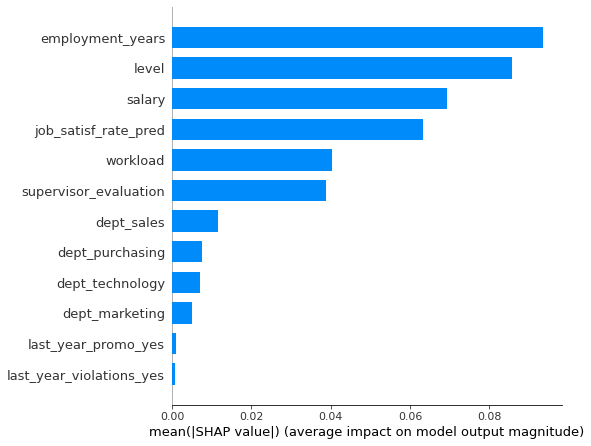

In [188]:
explainer = shap.KernelExplainer(randomized_search_2.best_estimator_['models'].predict_proba,\
                                 shap.sample(X_test_transformed_2, 50, random_state=RANDOM_STATE))

shap_values = explainer(shap.sample(X_test_transformed_2, 50, random_state=RANDOM_STATE))

shap.summary_plot(shap_values[:,:,1], plot_type='bar', max_display=15)

In [193]:
X_train_3 = X_train_.drop(['dept'], axis= 1)
X_test_3 = X_test_.drop(['dept'], axis= 1)

In [194]:
ohe_columns_3 = ['last_year_promo', 'last_year_violations']

ord_columns_3 = ['level', 'workload', 'supervisor_evaluation']

num_columns_3 = ['employment_years', 'salary', 'job_satisf_rate_pred']

In [195]:
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first', handle_unknown='ignore')
        )
    ]
) 

In [196]:
ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',  
            OrdinalEncoder(
                categories = [
                             ['junior', 'middle', 'sinior'],
                             ['low', 'medium', 'high'],
                             [1, 2, 3, 4, 5]
                            ],
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
        (
            'simpleImputer_after_ord', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
) 

In [197]:
data_preprocessor_3 = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns_3),
        ('ord', ord_pipe, ord_columns_3),
        ('num', StandardScaler(), num_columns_3)
    ], 
    remainder='passthrough'
) 

In [198]:
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor_3),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
) 

In [199]:
randomized_search_3 = RandomizedSearchCV(
    pipe_final, 
    param_distributions=param_rs, 
    scoring = 'roc_auc',
    cv=5,
    n_iter=50,
    random_state=RANDOM_STATE, 
    n_jobs=-1
)
randomized_search_3.fit(X_train_3, y_train_) 

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore'))]),
                                                                               ['last_year_promo',
                                                                                'last_year_violations']),
                                                                              ('ord',
                                                                               Pipeline(steps=[('simpleImpute...
                                         'models__n_neighbors': range(2, 20),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']},
                                        {'models': [LogisticRegression(class_weight='balanced',
                                                                       penalty='l1',
                                                                       random_state=42,
                                                                       solver='liblinear')],
                                         'models__C': range(1, 5),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']}],
                   random_state=42, scoring='roc_auc')

In [200]:
results = randomized_search_3.cv_results_
results_df = pd.DataFrame(results)
top_10_results = results_df.sort_values(by='mean_test_score', ascending=False).head(10)
display(top_10_results[['params', 'mean_test_score', 'std_test_score']])

print('Метрика ROC_AUC для лучшей модели: ', randomized_search_3.best_score_)
print('Лучшая модель и её параметры:\n\n', randomized_search_3.best_estimator_) 

,params,mean_test_score,std_test_score
20,"{'preprocessor__num': RobustScaler(), 'models_...",0.910456,0.011105
2,"{'preprocessor__num': StandardScaler(), 'model...",0.909824,0.011834
23,"{'preprocessor__num': RobustScaler(), 'models_...",0.907676,0.011120
45,"{'preprocessor__num': MinMaxScaler(), 'models_...",0.904886,0.010272
42,"{'preprocessor__num': MinMaxScaler(), 'models_...",0.903439,0.012772
12,"{'preprocessor__num': RobustScaler(), 'models_...",0.903302,0.012243
28,"{'preprocessor__num': StandardScaler(), 'model...",0.902815,0.013066
31,"{'preprocessor__num': 'passthrough', 'models__...",0.902793,0.014841
1,"{'preprocessor__num': StandardScaler(), 'model...",0.902793,0.014841
41,"{'preprocessor__num': StandardScaler(), 'model...",0.902177,0.010946


Метрика ROC_AUC для лучшей модели:  0.9104561531422949
Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_b

In [197]:
y_test_pred_3 = randomized_search_3.predict_proba(X_test_3)
y_test_pred_proba = y_test_pred_3[:, 1]
print('Метрика ROC-AUC на тестовой выборке:', roc_auc_score(y_test_, y_test_pred_proba))

Метрика ROC-AUC на тестовой выборке: 0.9155967867796677


**Вывод:**

Лучшей моделью по итогам подбора RandomizedSearchCV стала модель ближайших соседей с параметром n_neighbors = 19. Нам удалось улучшить качество модели удалением незначимого признака 'dept' и увеличения числа итераций RandomizedSearch до 50. В результате  улучшили метрику roc_auc модели на тестовой выборке до 91,6%

# Выводы

**Общий вывод:**

Перед нами стояла задача помочь HR-аналитикам компании «Работа с заботой» оптимизировать управление персоналом, для реализации которой мы выполнили две задачи:

1) Построили модель, предсказывающую уровень удовлетворённости работой сотрудников на основе данных заказчика

2) Предсказать отток сотрудников, построив модель, прогнозирующую увольнение сотрудников из компании

**Для решения первой задачи** мы обучили 2 модели: дерево решений и линейную регрессию, в качестве гипарпараметров использовали методы масштабирования, Для автоматического подбора гиперпараметров использовали инструмент RandomizedSearchCV

Для оценки работы модели мы создали метрику SMAPE («симметричное среднее абсолютное процентное отклонение») По итогам подбора лучшей моделью стала модель DecisionTreeRegressor со следующими параметрами: criterion='friedman_mse', max_depth=11, max_features=10, min_samples_leaf=4, min_samples_split=14. Метрика SMAPE на тестовой выборке - 14,09%

**Для решения второй задачи** мы обучили 3 модели: дерево решений, метод ближайших соседей и логистическую регрессию. На первом этапе получили достаточно выоскую метрику roc_auc на тестовой выборке (90,9%). Далее мы убрали незначимый признак 'dept', увеличили число итераций эстиматора RandomizedSearch, по итогам получили лучшую модель KNeighborClassifier с параметром n_neighbors = 19 и еще более высокой метрикой roc_auc на тестовой выборке 91,6%

По итогам исследовательского анализа данных мы увидели крайне низкий процент повышений (3% сотрудников) за последний год, высокую долю сотрудников начального уровня с низкими зарплатами и высокую текучку кадров этой категории сотрудников. В качестве увеличения мотивации и уровня удовлетворенности работой в компании можно предложить выстроить систему, позволяющую обучать сотрудников, стимулировать карьерный рост, увеличивать зону ответственности и зарплаты сотрудников уровня junior, обеспечить больше перспектив для повышения уровня занимаемой должности